# L² vs W₂ interpolations (Gaussians + Images)

This notebook generates 4 animations (GIF):

1. **L² interpolation** between two distant 2D Gaussians (mixture / crossfade)
2. **L² interpolation** between two images (pixelwise crossfade)
3. **W₂ interpolation** between two distant 2D Gaussians (displacement / translation of the mean)
4. **W₂ interpolation** between two images (displacement interpolation using an OT coupling; Sinkhorn by default)

**Dependencies**
- `numpy`, `pillow`, `imageio`
- Optional: `pot` (Python Optimal Transport) for exact EMD on images (can be slow)

All outputs are saved in `OUT_DIR`.


In [21]:
# If needed, install dependencies (uncomment):
# !pip install -q numpy pillow imageio
# Optional (exact OT):
# !pip install -q pot

In [22]:
import os
import numpy as np
import imageio.v2 as imageio
from PIL import Image, ImageDraw, ImageFont

In [23]:
# ---------- Configuration ----------
OUT_DIR = "out_wgf"
os.makedirs(OUT_DIR, exist_ok=True)

FRAMES = 5*24
FPS = 24

In [24]:
def to_rgb_frame(mat, vmax=None, upscale=6):
    """Convert 2D array to an upscaled grayscale RGB uint8 image."""
    mat = np.asarray(mat, dtype=np.float64)
    if vmax is None:
        vmax = float(np.max(mat)) if np.max(mat) > 0 else 1.0
    x = np.clip(mat / vmax, 0.0, 1.0)
    img = (x * 255.0).astype(np.uint8)
    if upscale and upscale > 1:
        img = np.kron(img, np.ones((upscale, upscale), dtype=np.uint8))
    return np.stack([img, img, img], axis=-1)

def save_gif(mats, out_path, fps=15, vmax=None, upscale=6):
    frames = [to_rgb_frame(M, vmax=vmax, upscale=upscale) for M in mats]
    imageio.mimsave(out_path, frames, fps=fps)
    return out_path

def normalize_density(a, eps=1e-12):
    a = np.maximum(np.asarray(a, dtype=np.float64), 0.0)
    s = float(a.sum())
    if s < eps:
        a = a + 1.0
        s = float(a.sum())
    return a / s

In [25]:
# # ---------- Gaussians: L2 vs W2 ----------
# def gaussian2d_grid(N, extent, mean, sigma):
#     x = np.linspace(extent[0], extent[1], N)
#     X, Y = np.meshgrid(x, x, indexing="xy")
#     dx = X - mean[0]
#     dy = Y - mean[1]
#     s2 = sigma * sigma
#     rho = np.exp(-(dx * dx + dy * dy) / (2 * s2)) / (2 * np.pi * s2)
#     return normalize_density(rho)

# def make_gaussian_animations(out_dir, frames=40, N=180, extent=(-6, 6), sigma=(0.8, 0.8),
#                              m0=(-3.5, 0.0), m1=(3.5, 0.0), fps=15):
#     m0 = np.array(m0, dtype=np.float64)
#     m1 = np.array(m1, dtype=np.float64)

#     sigma1, sigma2 = sigma

#     rho0 = gaussian2d_grid(N, extent, m0, sigma1)
#     rho1 = gaussian2d_grid(N, extent, m1, sigma2)
#     vmax = float(max(rho0.max(), rho1.max()))
#     ts = np.linspace(0, 1, frames)

#     # (1) L2 interpolation (mixture / crossfade)
#     mats_l2 = [(1.0 - t) * rho0 + t * rho1 for t in ts]
#     p1 = os.path.join(out_dir, "1_l2_gaussians.gif")
#     save_gif(mats_l2, p1, fps=fps, vmax=vmax, upscale=3)

#     # (3) W2 displacement interpolation (exact here: translate the mean)
#     mats_w2 = []
#     for t in ts:
#         mt = (1.0 - t) * m0 + t * m1
#         mats_w2.append(gaussian2d_grid(N, extent, mt, sigma))
#     p3 = os.path.join(out_dir, "3_w2_gaussians.gif")
#     save_gif(mats_w2, p3, fps=fps, vmax=vmax, upscale=3)

#     return p1, p3

In [26]:
def gaussian_pdf_1d(x, m, s):
    s = float(s)
    return np.exp(-0.5 * ((x - m) / s) ** 2) / (np.sqrt(2 * np.pi) * s)

def lerp_color_rgb(t, c0=(0, 0, 255), c1=(255, 0, 0)):
    """Linear interpolation between two RGB colors."""
    t = float(np.clip(t, 0.0, 1.0))
    return tuple(int(round((1 - t) * a + t * b)) for a, b in zip(c0, c1))

def render_density_frame(x, y, y_max, width=800, height=320, margin=35,
                         line_width=3, line_color=(0,0,0), label=None):
    """
    Render y(x) with a fixed y-axis max = y_max, and a chosen line color.
    """
    x = np.asarray(x, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)

    xmin, xmax = float(x.min()), float(x.max())
    y_max = float(max(y_max, 1e-12))

    def X(u):
        return int(margin + (u - xmin) / (xmax - xmin) * (width - 2 * margin))

    def Y(v):
        v = np.clip(v, 0.0, y_max)
        return int(height - margin - (v / y_max) * (height - 2 * margin))

    img = Image.new("RGB", (width, height), (255, 255, 255))
    draw = ImageDraw.Draw(img)

    # Axes
    draw.line((margin, height - margin, width - margin, height - margin), fill=(180, 180, 180), width=1)
    draw.line((margin, height - margin, margin, margin), fill=(180, 180, 180), width=1)

    # Curve
    pts = [(X(xi), Y(yi)) for xi, yi in zip(x, y)]
    draw.line(pts, fill=line_color, width=line_width)

    # Label
    if label is not None:
        draw.text((margin + 5, margin + 5), label, fill=(0, 0, 0))

    return np.array(img, dtype=np.uint8)

def make_gif(frames, path, fps=15):
    imageio.mimsave(path, frames, fps=fps)
    return path

def make_gaussian1d_animations_colored(out_dir, frames=40, fps=15,
                                       m0=-4.0, s0=0.7,
                                       m1= 4.0, s1=1.8,
                                       x_min=None, x_max=None, n_grid=1600):
    if x_min is None or x_max is None:
        pad = 6.0 * max(s0, s1)
        x_min = min(m0, m1) - pad
        x_max = max(m0, m1) + pad

    x = np.linspace(x_min, x_max, n_grid)
    rho0 = gaussian_pdf_1d(x, m0, s0)
    rho1 = gaussian_pdf_1d(x, m1, s1)
    ts = np.linspace(0.0, 1.0, frames)

    y_max_l2 = float(max(rho0.max(), rho1.max()))
    y_max_w2 = float(1.0 / (np.sqrt(2*np.pi) * min(s0, s1)))

    # (1) L2 interpolation (colored)
    frames_l2 = []
    for t in ts:
        rho_t = (1.0 - t) * rho0 + t * rho1
        col = lerp_color_rgb(t, (0, 0, 255), (255, 0, 0))
        frames_l2.append(render_density_frame(
            x, rho_t, y_max=y_max_l2, line_color=col, label=f"L²   t={t:.2f}"
        ))
    p1 = os.path.join(out_dir, "1_l2_gaussians.gif")
    make_gif(frames_l2, p1, fps=fps)

    # (3) W2 interpolation between Gaussians (exact in 1D, colored)
    frames_w2 = []
    for t in ts:
        mt = (1.0 - t) * m0 + t * m1
        st = (1.0 - t) * s0 + t * s1
        rho_t = gaussian_pdf_1d(x, mt, st)
        col = lerp_color_rgb(t, (0, 0, 255), (255, 0, 0))
        frames_w2.append(render_density_frame(
            x, rho_t, y_max=y_max_w2, line_color=col, label=f"W₂   t={t:.2f}"
        ))
    p3 = os.path.join(out_dir, "3_w2_gaussians.gif")
    make_gif(frames_w2, p3, fps=fps)

    return p1, p3

In [33]:
# ---------- Images: L2 vs W2 ----------
def load_image_as_density(path, N=32, invert=False):
    img = Image.open(path).convert("L").resize((N, N), resample=Image.BICUBIC)
    arr = np.asarray(img, dtype=np.float64)
    if invert:
        arr = 255.0 - arr
    return normalize_density(arr)

def synthetic_density_pair(N=32, supersample=4):
    def normalize_density(a, eps=1e-12):
        a = np.maximum(np.asarray(a, dtype=np.float64), 0.0)
        s = float(a.sum())
        if s < eps:
            a = a + 1.0
            s = float(a.sum())
        return a / s

    def downsample(img_hi):
        return img_hi.resize((N, N), resample=Image.BICUBIC)

    def draw_disk_left():
        S = N * supersample
        img = Image.new("L", (S, S), 0)
        d = ImageDraw.Draw(img)
        r = int(0.20 * S)
        cx, cy = int(0.28 * S), int(0.50 * S)
        d.ellipse((cx - r, cy - r, cx + r, cy + r), fill=255)
        return downsample(img)

    def draw_plus_right():
        S = N * supersample
        img = Image.new("L", (S, S), 0)
        d = ImageDraw.Draw(img)
        # center on the right
        cx, cy = int(0.72 * S), int(0.50 * S)
        thickness = max(1, int(0.10 * S))
        length = int(0.2 * S)
        # vertical bar
        d.rectangle((cx - thickness//2, cy - length, cx + thickness//2, cy + length), fill=255)
        # horizontal bar
        d.rectangle((cx - length, cy - thickness//2, cx + length, cy + thickness//2), fill=255)
        return downsample(img)

    A_img = draw_disk_left()
    B_img = draw_plus_right()

    A = np.asarray(A_img, dtype=np.float64)
    B = np.asarray(B_img, dtype=np.float64)

    return normalize_density(A), normalize_density(B)

def make_cost_matrix_grid(N):
    """Squared Euclidean cost matrix on an NxN grid in [0,1]^2."""
    xs = np.linspace(0.0, 1.0, N)
    X, Y = np.meshgrid(xs, xs, indexing="ij")
    coords = np.stack([X.ravel(), Y.ravel()], axis=1)  # (n,2)
    diff = coords[:, None, :] - coords[None, :, :]
    C = np.sum(diff * diff, axis=2)
    return coords, C

def sinkhorn(a, b, C, eps=0.03, n_iters=500):
    """Balanced entropic OT via Sinkhorn scaling. Returns coupling pi."""
    a = np.asarray(a, dtype=np.float64)
    b = np.asarray(b, dtype=np.float64)
    K = np.exp(-C / eps)
    K = np.maximum(K, 1e-300)
    u = np.ones_like(a)
    v = np.ones_like(b)
    for _ in range(n_iters):
        Kv = K @ v
        Kv = np.maximum(Kv, 1e-300)
        u = a / Kv
        KTu = K.T @ u
        KTu = np.maximum(KTu, 1e-300)
        v = b / KTu
    return (u[:, None] * K) * v[None, :]

def emd_pot(a, b, C):
    """Exact OT via POT (pip install pot). Returns coupling pi."""
    import ot
    return ot.emd(a, b, C)

def splat_to_grid(zx, zy, w, N):
    """Bilinear splat of masses at (zx,zy)∈[0,1]^2 back to an NxN grid."""
    zx = np.asarray(zx, dtype=np.float64)
    zy = np.asarray(zy, dtype=np.float64)
    w = np.asarray(w, dtype=np.float64)
    i = zx * (N - 1)
    j = zy * (N - 1)
    i0 = np.floor(i).astype(np.int32)
    j0 = np.floor(j).astype(np.int32)
    i1 = np.minimum(i0 + 1, N - 1)
    j1 = np.minimum(j0 + 1, N - 1)
    di = i - i0
    dj = j - j0
    w00 = w * (1 - di) * (1 - dj)
    w01 = w * (1 - di) * dj
    w10 = w * di * (1 - dj)
    w11 = w * di * dj
    idx00 = i0 * N + j0
    idx01 = i0 * N + j1
    idx10 = i1 * N + j0
    idx11 = i1 * N + j1
    out = np.bincount(idx00, w00, minlength=N * N)
    out += np.bincount(idx01, w01, minlength=N * N)
    out += np.bincount(idx10, w10, minlength=N * N)
    out += np.bincount(idx11, w11, minlength=N * N)
    return out.reshape((N, N))

def make_image_animations(out_dir, imgA=None, imgB=None, N=32, frames=40, fps=15,
                          ot_method="sinkhorn", sinkhorn_eps=0.03, sinkhorn_iters=500,
                          invert=False):
    """
    Creates:
      (2) L2 interpolation GIF (pixelwise)
      (4) W2 interpolation GIF (displacement via OT coupling)
    """
    if imgA and imgB:
        A = load_image_as_density(imgA, N=N, invert=invert)
        B = load_image_as_density(imgB, N=N, invert=invert)
    else:
        A, B = synthetic_density_pair(N=N)

    vmax = float(max(A.max(), B.max()))
    ts = np.linspace(0, 1, frames)

    # (2) L2 interpolation
    mats_l2 = [(1 - t) * A + t * B for t in ts]
    p2 = os.path.join(out_dir, "2_l2_images.gif")
    save_gif(mats_l2, p2, fps=fps, vmax=vmax, upscale=8)

    # (4) W2 interpolation
    coords, C = make_cost_matrix_grid(N)
    a = A.ravel()
    b = B.ravel()

    if ot_method.lower() == "emd":
        try:
            pi = emd_pot(a, b, C)
        except Exception as e:
            print(f"[warn] POT/EMD failed ({e}). Falling back to Sinkhorn.")
            pi = sinkhorn(a, b, C, eps=sinkhorn_eps, n_iters=sinkhorn_iters)
    else:
        pi = sinkhorn(a, b, C, eps=sinkhorn_eps, n_iters=sinkhorn_iters)

    x0 = coords[:, 0]
    x1 = coords[:, 1]
    y0 = coords[:, 0]
    y1 = coords[:, 1]
    Y0 = y0[None, :]
    Y1 = y1[None, :]

    mats_w2 = []
    for t in ts:
        ZX = ((1 - t) * x0[:, None] + t * Y0).ravel()
        ZY = ((1 - t) * x1[:, None] + t * Y1).ravel()
        W = pi.ravel()
        Mt = splat_to_grid(ZX, ZY, W, N)
        Mt = normalize_density(Mt)
        mats_w2.append(Mt)

    p4 = os.path.join(out_dir, "4_w2_images.gif")
    save_gif(mats_w2, p4, fps=fps, vmax=vmax, upscale=8)

    # Save endpoints for reference
    Image.fromarray((A / A.max() * 255).astype(np.uint8)).save(os.path.join(out_dir, "A_endpoint.png"))
    Image.fromarray((B / B.max() * 255).astype(np.uint8)).save(os.path.join(out_dir, "B_endpoint.png"))

    return p2, p4

In [ ]:
# ---------- Run everything ----------
# 1) & 3) Gaussians
p1, p3 = make_gaussian1d_animations_colored(
    out_dir=OUT_DIR, frames=FRAMES, fps=FPS,
    m0=-4.0, s0=0.7,
    m1= 4.0, s1=1.8
)

# 2) & 4) Images
# Option A: use synthetic blobs (no external files)
p2, p4 = make_image_animations(
    out_dir=OUT_DIR,
    imgA=None,
    imgB=None,
    N=64,               # keep <= 48 to avoid huge cost matrices
    frames=FRAMES,
    fps=FPS,
    ot_method="sinkhorn",   # or "emd" if you installed POT and can wait
    sinkhorn_eps=0.03,
    sinkhorn_iters=500,
    invert=False
)

p1, p2, p3, p4

('out_wgf\\1_l2_gaussians.gif',
 'out_wgf\\2_l2_images.gif',
 'out_wgf\\3_w2_gaussians.gif',
 'out_wgf\\4_w2_images.gif')

## Display results in-notebook (optional)

Run the cell below to display the generated GIFs directly in the notebook.


out_wgf\1_l2_gaussians.gif


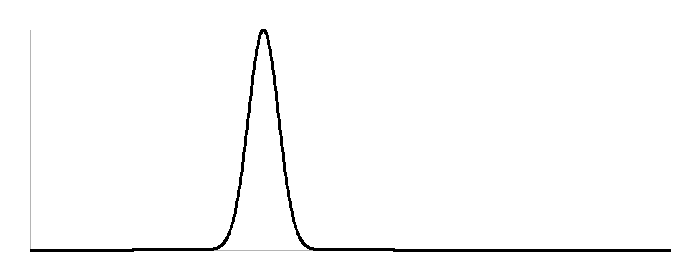

out_wgf\2_l2_images.gif


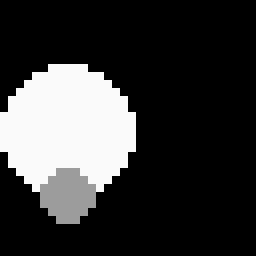

out_wgf\3_w2_gaussians.gif


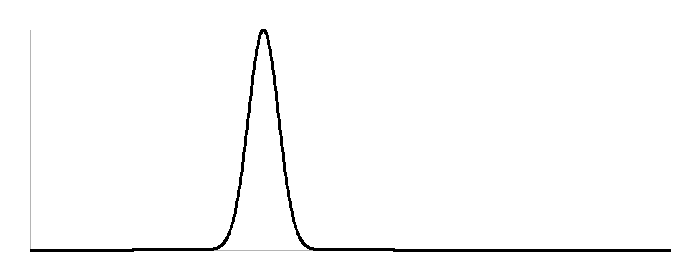

out_wgf\4_w2_images.gif


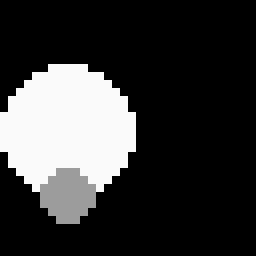

In [7]:
from IPython.display import Image as IPyImage, display

for name in ["1_l2_gaussians.gif", "2_l2_images.gif", "3_w2_gaussians.gif", "4_w2_images.gif"]:
    path = os.path.join(OUT_DIR, name)
    print(path)
    display(IPyImage(filename=path))

## Using your own images

Set `imgA_path` and `imgB_path` below and rerun the *Images* part.

Tips:
- Convert your images to grayscale, or just let the loader do it.
- Keep `N` small (32–48) to keep OT cost matrices manageable.
- For sharper W₂ motion, reduce `sinkhorn_eps` (e.g. 0.01), but you may need more iterations.


In [ ]:
imgA_path = "path/to/A.png"
imgB_path = "path/to/B.png"

# Uncomment when you set real paths:
# p2, p4 = make_image_animations(
#     out_dir=OUT_DIR,
#     imgA=imgA_path,
#     imgB=imgB_path,
#     N=40,
#     frames=FRAMES,
#     fps=FPS,
#     ot_method="sinkhorn",
#     sinkhorn_eps=0.02,
#     sinkhorn_iters=800,
#     invert=False
# )
# (p2, p4)
